# Analysis

In [375]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import missingno as msno
sns.set_theme(style='darkgrid')
import matplotlib.pyplot as plt

In [376]:
data = pd.read_csv('Assignment/DataSets/preprocessed_data.csv')

In [377]:
data.dtypes

Peso                              float64
Altura                              int64
IMC                               float64
Idade                               int64
Pulsos                             object
SBP                               float64
DBP                               float64
Result SBP-DBP                     object
B2                                 object
Sopro                              object
FC                                float64
HDA1                               object
HDA2                               object
Sexo                               object
Motivo1                            object
Motivo2                            object
Intervalo Idade                    object
Percentil IMC                      object
Systolic Blood Pressure (SBP)      object
Diastolic Blood Pressure (DBP)     object
Patologia                          object
dtype: object

## Bivariate analysis

A **análise bivariada** consiste em analisar exatamente **duas variáveis simultaneamente** para ```determinar se existe uma relação empírica entre elas```.

Ao contrário da análise univariada (que resume apenas uma variável, ex: "qual a média de idades?"), a bivariada tenta responder a perguntas de causa e efeito ou associação, como:

* "O aumento da Idade está relacionado com o aumento da SBP (Pressão Sistólica)?"

* "Existe diferença significativa no IMC entre os diferentes Sexos?"

Existem **três tipos principais de análise bivariada**, dependendo do tipo de dados:

* ```Numérica e Numérica:``` (Ex: Peso vs. Altura). Usa-se **Correlação** e **Regressão Linear**.

* ```Numérica e Categórica:```(Ex: IMC vs. Sexo). Usa-se Boxplots ou testes-T.

* ```Categórica e Categórica:``` (Ex: Sexo vs. Patologia). Usa-se testes Qui-quadrado (Chi-square).

> **Nota:** Neste caso apenas vamos fazer **análise bivariada** para **váriavies Númericas**, porque no enunciado indicou **correlação** e **regressão**

![alt text](img/image-5.PNG)


In [378]:
numeric_features = [
    'Peso', 'Altura', 'IMC', 'Idade', 
    'SBP', 'DBP', 'FC'
]

data_analysis = data[numeric_features]

### Correlation 

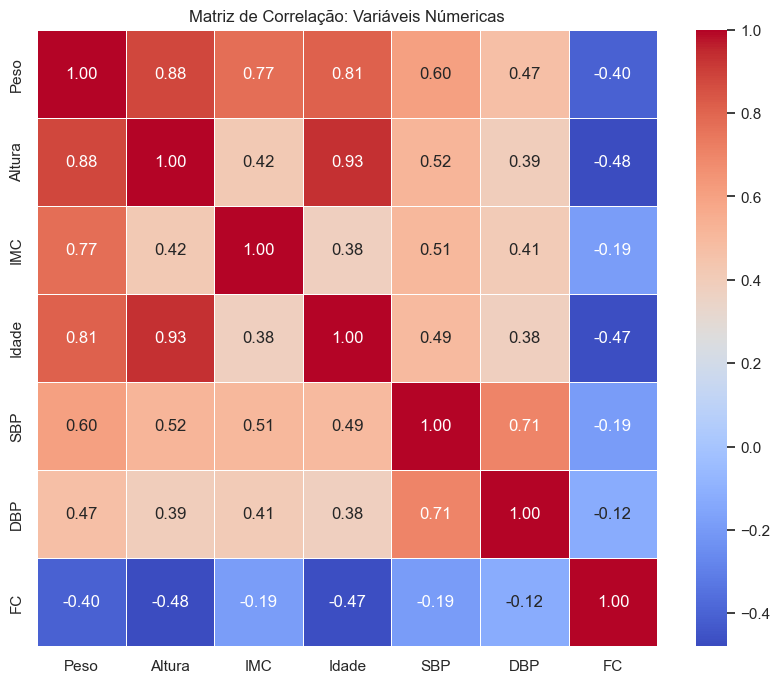

In [379]:
correlation_matrix = data_analysis.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, 
            annot=True,       
            cmap='coolwarm',  
            fmt=".2f",        
            linewidths=0.5)

plt.title('Matriz de Correlação: Variáveis Númericas')
plt.show()

In [380]:
correlacoes = correlation_matrix.unstack()
correlacoes_ordenadas = correlacoes.sort_values(ascending=False)
correlacoes_positivas = correlacoes_ordenadas[(correlacoes_ordenadas < 1) & (correlacoes_ordenadas > 0.75)]
df_corr_pos = pd.DataFrame(correlacoes_positivas, columns=['Correlação'])
df_corr_pos = df_corr_pos.drop_duplicates()
print("Par de varíavies que estão altamente correlacionadas >0.75 (estão a fornecer a mesma informação)")
print(df_corr_pos)

Par de varíavies que estão altamente correlacionadas >0.75 (estão a fornecer a mesma informação)
              Correlação
Altura Idade    0.932452
       Peso     0.879230
Idade  Peso     0.809501
Peso   IMC      0.774259


### Regression

#### Simple regression

<Figure size 800x600 with 0 Axes>

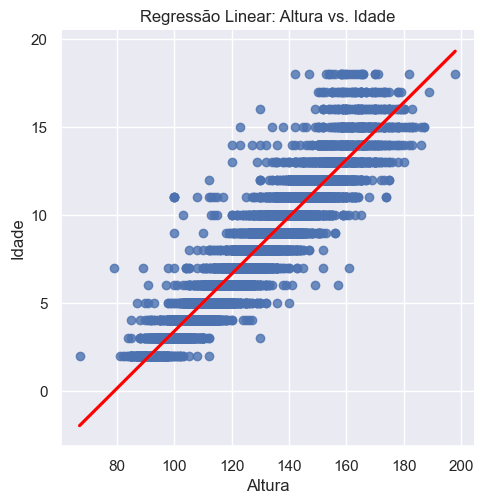

<Figure size 800x600 with 0 Axes>

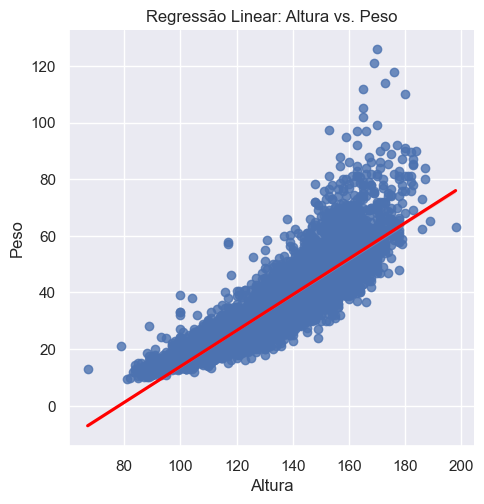

<Figure size 800x600 with 0 Axes>

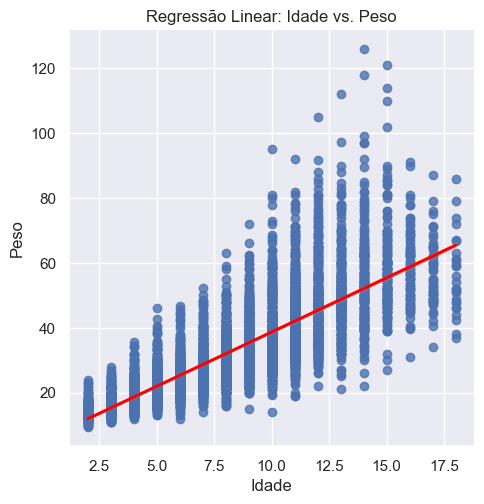

<Figure size 800x600 with 0 Axes>

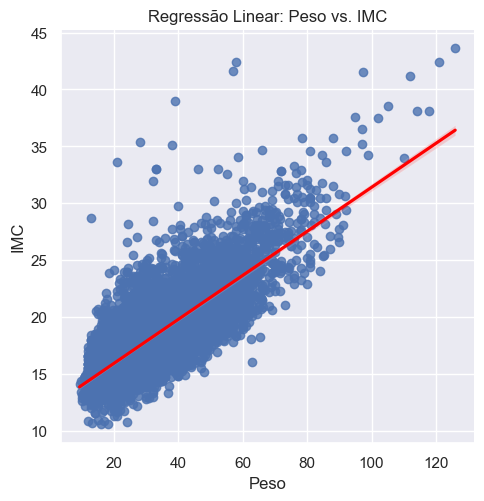

In [381]:
# We only do regression on higly correlated pairs (in this case correlation > 0.75)
highly_correlated_pairs = [['Altura','Idade'],['Altura','Peso'],['Idade','Peso'],['Peso','IMC']]

for p in highly_correlated_pairs:
    f1 = p[0]
    f2 = p[1]
    plt.figure(figsize=(8, 6))
    sns.lmplot(x=f1, y=f2, data=data_analysis, line_kws={'color': 'red'});
    plt.title(f'Regressão Linear: {f1} vs. {f2}')
    plt.show()

#### Statistical Regression

* **R-squared (R²):** Indica a **% da variação** de ```Y```(váriavel dependente) que **é explicada por** ```X``` (váriavel Independente). 
    * Lê-se : "Quero prever ```Y``` com base em ```X```" ou  "```X``` influencia o valor de ```Y```?"
    * e.g R² for 0.30, Y = 'SBP' e X = 'Idade', então a Idade explica 30% da variação de SBP.

* **Coeficiente**(X = Idade e Y=SBP): Se for, por exemplo, 0.5, **significa que por cada 1 ano que a pessoa envelhece, a SBP sobe, em média, 0.5 unidades**.

In [382]:
import statsmodels.api as sm
# Lista corrigida para fazer sentido biológico: [Y (Dependente), X (Independente)]
# Lê-se: "Quero prever Y com base em X" ou "X influencia o valor de Y?"
logical_pairs = [
    ['Altura', 'Idade'],  # Idade influencia a Altura
    ['Peso', 'Altura'],   # Altura influencia o Peso 
    ['Peso', 'Idade'],    # Idade influencia o Peso
    ['IMC', 'Peso']       # Peso influencia o IMC
]

for p in logical_pairs:
    target = p[0]    # Y
    predictor = p[1] # X
    
    print(f"--- Analisando: {target} (Y) vs {predictor} (X) ---")

    Y = data_analysis[target]
    X = data_analysis[predictor]
    X = sm.add_constant(X) 

    modelo = sm.OLS(Y, X).fit()
    print(f"R-squared: {modelo.rsquared:.4f}")
    print(f"Coeficiente: {modelo.params[predictor]:.4f}")
    print("\n")

--- Analisando: Altura (Y) vs Idade (X) ---
R-squared: 0.8695
Coeficiente: 5.3480


--- Analisando: Peso (Y) vs Altura (X) ---
R-squared: 0.7730
Coeficiente: 0.6338


--- Analisando: Peso (Y) vs Idade (X) ---
R-squared: 0.6553
Coeficiente: 3.3469


--- Analisando: IMC (Y) vs Peso (X) ---
R-squared: 0.5995
Coeficiente: 0.1932




"A análise de regressão linear revelou correlações positivas fortes e estatisticamente robustas entre as variáveis.O destaque principal vai para a relação Idade vs. Altura ($R^2 \approx 0.87$), que apresentou o maior poder explicativo do modelo. Observou-se também que, embora a Idade seja um excelente preditor da Altura, ela prediz o Peso com ligeiramente menos precisão ($R^2 \approx 0.65$), o que é esperado dado que o peso sofre maior influência de fatores externos (nutrição/ambiente) do que o crescimento ósseo."

## Multivariate analysis

Multivariate analysis is a powerful technique that allows us to explore relationships between multiple variables simultaneously. It helps uncover hidden patterns and deeper insights that are often missed in univariate or bivariate analyses

### Data preparation

In [383]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. Definir as listas de features
numeric_features = ['Peso', 'Altura', 'IMC', 'Idade', 'SBP', 'DBP', 'FC']
# Categorias que trazem informação nova (não redundante)
categorical_features = ['Pulsos', 'Result SBP-DBP', 'B2', 'Sopro', 'HDA1', 'HDA2', 'Sexo', 'Motivo1', 'Motivo2'] 

cols_to_use = numeric_features + categorical_features + ['Patologia']
df_clean = data[cols_to_use].dropna()

# --- PREPARAÇÃO DO ALVO (Y) ---
# O y é igual para todos os casos
y = df_clean['Patologia']
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Classes Alvo:", dict(zip(le.classes_, le.transform(le.classes_))))

# Guardar o mapeamento para saberes o que é o quê no final
class_names = list(le.classes_)


# --- CONJUNTO 1: APENAS NUMÉRICO (X_num) ---
# Útil para: K-Means (puro) e Baseline
X_num_raw = df_clean[numeric_features]

scaler_num = StandardScaler()
X_num_scaled = scaler_num.fit_transform(X_num_raw)
# Variável final para usar: X_num_scaled


# --- CONJUNTO 2: Númerico e Categorico - COMPLETO (X_all) ---
# Útil para: Regressão Múltipla e Mutual Information
X_all_raw = df_clean[numeric_features + categorical_features]

# Aplicar One-Hot Encoding nas categóricas
# drop_first=True reduz a colinearidade (bom para regressão)
X_all_encoded = pd.get_dummies(X_all_raw, columns=categorical_features)

# Escalar tudo (Números originais + Dummies)
scaler_all = StandardScaler()
X_all_scaled = scaler_all.fit_transform(X_all_encoded)
# Variável final para usar: X_all_scaled


# --- VERIFICAÇÃO ---
print(f"\nLinhas totais (Pacientes): {len(y)}")
print(f"Features no set Numérico (X_num_scaled): {X_num_scaled.shape[1]}")
print(f"Features no set Completo (X_all_scaled): {X_all_scaled.shape[1]}")

Classes Alvo: {'Anormal': np.int64(0), 'Normal': np.int64(1)}

Linhas totais (Pacientes): 6293
Features no set Numérico (X_num_scaled): 7
Features no set Completo (X_all_scaled): 48


### Multiple Linear Regression

* **Análise:** Verificar quais são as varíaveis, que mais influenciam a classificação '''Normal''' ou '''Anormal'''.

#### Creating a  Multiple Linear Regression model

In [384]:

from sklearn.model_selection import train_test_split
# 1. Dividir em Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(X_all_scaled, y_encoded, test_size=0.3, random_state=42)


In [385]:
from sklearn.linear_model import LogisticRegression
# Criar o modelo
# solver='lbfgs' e multi_class='multinomial' são padrão para multiclasse
model = LogisticRegression(max_iter=2000, random_state=42)

# Treinar
model.fit(X_train, y_train)

# Prever no conjunto de teste
y_pred = model.predict(X_test)

#### Performance Analysis

--- Performance da Regressão Múltipla (Logística) ---
              precision    recall  f1-score   support

     Anormal       0.95      0.85      0.90       645
      Normal       0.93      0.98      0.95      1243

    accuracy                           0.93      1888
   macro avg       0.94      0.91      0.93      1888
weighted avg       0.94      0.93      0.93      1888



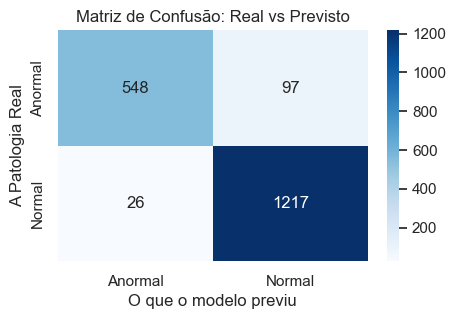

In [386]:
from sklearn.metrics import classification_report, confusion_matrix
# Relatório Estatístico
print("--- Performance da Regressão Múltipla (Logística) ---")
print(classification_report(y_test, y_pred, target_names=class_names))

# Visualizar Matriz de Confusão
plt.figure(figsize=(5, 3))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusão: Real vs Previsto')
plt.xlabel('O que o modelo previu')
plt.ylabel('A Patologia Real')
plt.show()

#### Coeficient Analysis for both 'Normal' and 'Anormal' pathologies

* Caso 1: ```Se a análise for a classe 'Normal'```


| Coeficiente | O que significa? | Exemplo Prático
| - | - | - |
| **Positivo (+)** | Confirma Saúde. Indica que o paciente está bem. (i.e. maior probabilidade de ter target feature (Patologia) **igual a **Normal**, ou seja, não tem a patologia)  | Ter "Sem Sopro" (+3.0)→ É muito provável ser Normal. |
| **Zero (0)** | Neutro. Não serve para nada. | "Altura" (0.01) → Não ajuda a decidir.| 
| **Negativo (-)** | Indica Doença. Afasta a hipótese de ser saudável.(i.e. maior probabilidade de ter target feature (Patologia) **igual a Anormal, ou seja,  tem a patologia**) | "Sem Sopro" (-3.0) → É muito provável ser Normal."|


>**Nota:** "Coeficientes positivos 'puxam' a decisão para a classe que estamos a analisar. Coeficientes negativos 'empurram' a decisão para a classe oposta."

In [387]:
class_names

['Anormal', 'Normal']

O Scikit-Learn está a calcular coeficientes para a classe: Normal


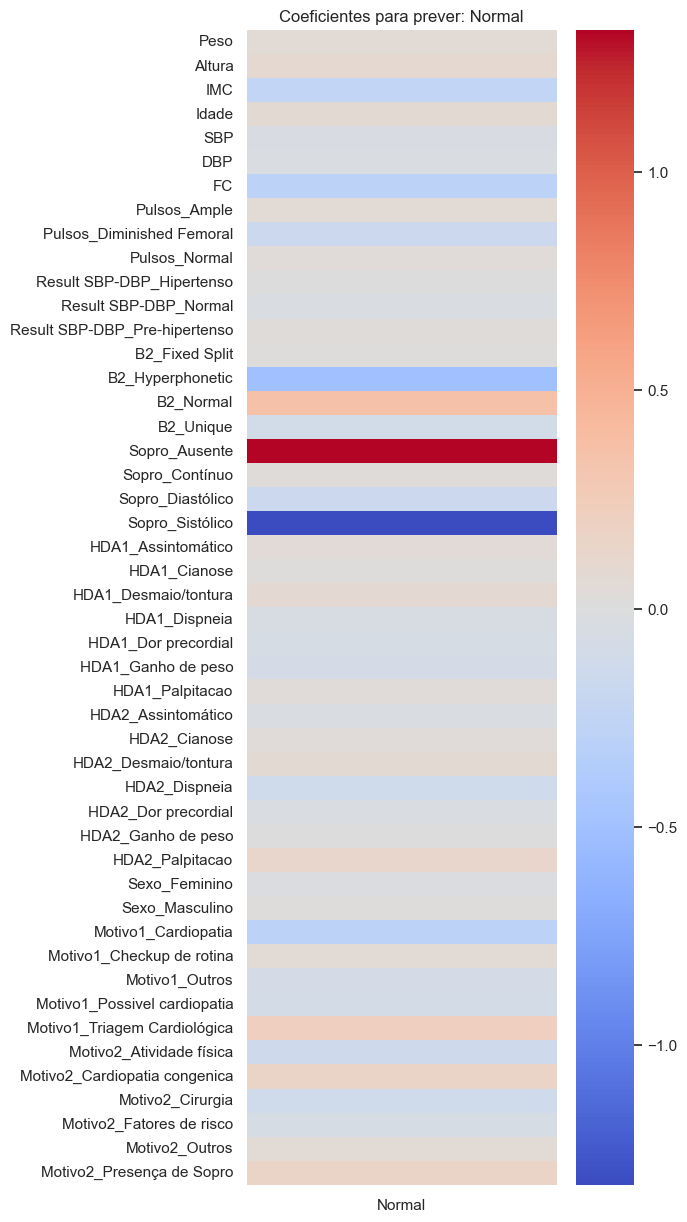


--- O que aumenta a probabilidade de ser 'Normal'? ---
Sopro_Ausente                    1.325904
B2_Normal                        0.362184
Motivo1_Triagem Cardiológica     0.217315
Motivo2_Cardiopatia congenica    0.151848
Motivo2_Presença de Sopro        0.150262
Name: Normal, dtype: float64

--- O que diminui a probabilidade de 'Normal' (logo, indica 'Anormal')? ---
IMC                   -0.244498
FC                    -0.292838
Motivo1_Cardiopatia   -0.293263
B2_Hyperphonetic      -0.513155
Sopro_Sistólico       -1.320056
Name: Normal, dtype: float64


In [388]:
feature_names = X_all_encoded.columns 

# Verificar qual é a classe positiva (índice 1)
classe_positiva = class_names[1]  # Muito provavelmente é 'Normal'
classe_negativa = class_names[0]  # Muito provavelmente é 'Anormal'

print(f"O Scikit-Learn está a calcular coeficientes para a classe: {classe_positiva}")

coefs_df = pd.DataFrame(model.coef_, columns=feature_names, index=[classe_positiva])
coefs_df = coefs_df.T

# Visualizar
plt.figure(figsize=(5, 15))
sns.heatmap(coefs_df, cmap='coolwarm', center=0, annot=False)
plt.title(f'Coeficientes para prever: {classe_positiva}')
plt.show()

# Análise Corrigida
series_analise = coefs_df.iloc[:,0]
top_features = series_analise.sort_values(ascending=False)

print(f"\n--- O que aumenta a probabilidade de ser '{classe_positiva}'? ---")
print(top_features.head(5))

print(f"\n--- O que diminui a probabilidade de '{classe_positiva}' (logo, indica '{classe_negativa}')? ---")
print(top_features.tail(5))


### Mutual Information (MI)

* **Análise:** As variáveis no topo (com maior score de Mutual Information) são as mais importantes.

#### MI with Categorical and Numerical Features

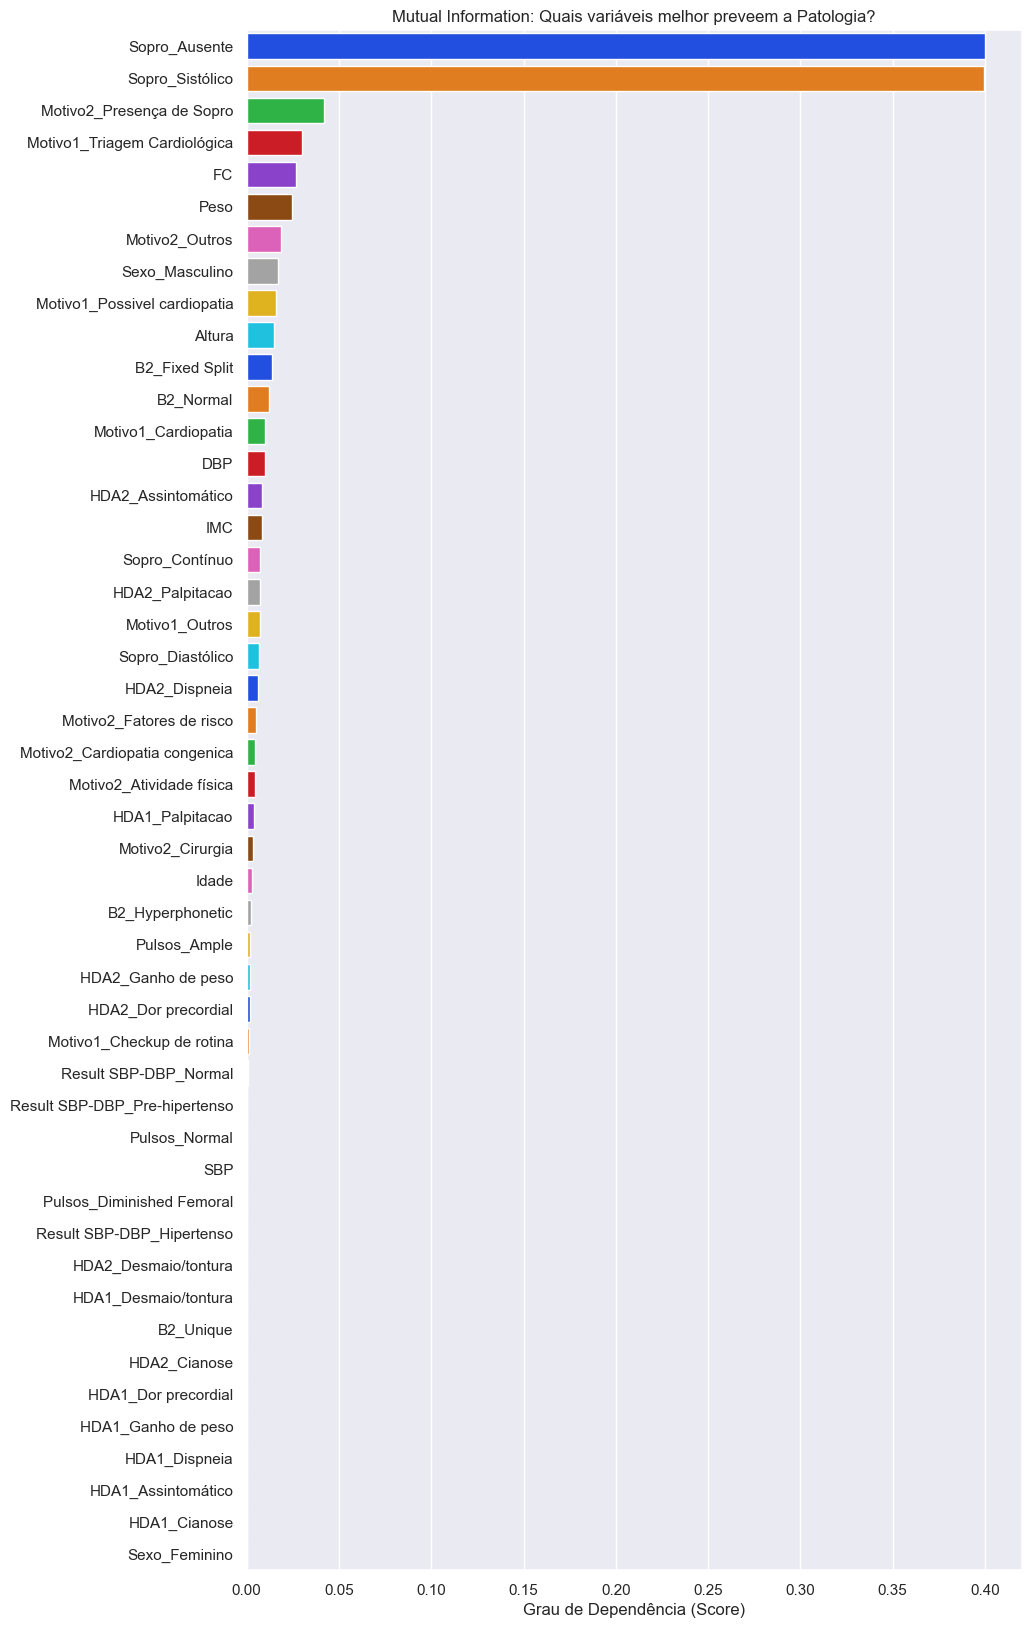

In [389]:
from sklearn.feature_selection import mutual_info_classif

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


# Calcular a importância
mi_scores = mutual_info_classif(X_all_scaled, y_encoded, random_state=42)
mi_series = pd.Series(mi_scores, index=X_all_encoded.columns).sort_values(ascending=False)

# Visualizar
plt.figure(figsize=(10, 20))
sns.barplot(x=mi_series.values, y=mi_series.index, palette='bright')
plt.ylabel('')
plt.title('Mutual Information: Quais variáveis melhor preveem a Patologia?')
plt.xlabel('Grau de Dependência (Score)')
plt.show()

#### MI with Numerical Features only

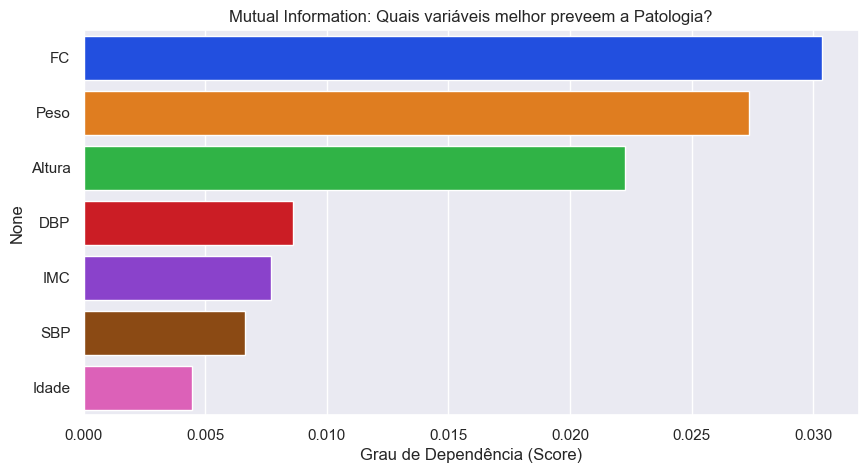

In [390]:
from sklearn.feature_selection import mutual_info_classif

# Calcular a importância
mi_scores = mutual_info_classif(X_num_scaled, y_encoded, random_state=42)
mi_series = pd.Series(mi_scores, index=X_num_raw.columns).sort_values(ascending=False)

# Visualizar
plt.figure(figsize=(10, 5))
sns.barplot(x=mi_series.values, y=mi_series.index, palette='bright')
plt.title('Mutual Information: Quais variáveis melhor preveem a Patologia?')
plt.xlabel('Grau de Dependência (Score)')
plt.show()

### KMeans

Para a análise de K-Means (Clustering), vou usar X_num_scaled (apenas as variáveis numéricas contínuas), visto que o K-Means calcula distâncias geométricas.

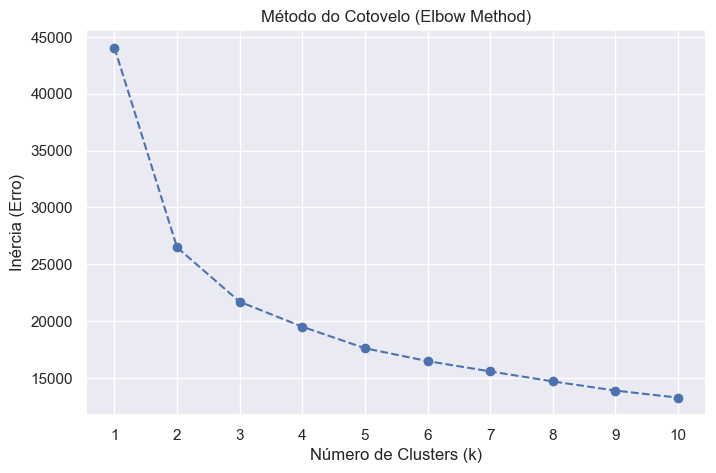

In [391]:
from sklearn.cluster import KMeans

# Vamos usar as variáveis NUMÉRICAS para agrupar fisicamente os pacientes
X_cluster = X_num_scaled 

inertia = []
K_range = range(1, 11)

for k in K_range:
    # n_init=10 corre o algoritmo 10 vezes e escolhe o melhor, garantindo estabilidade
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster)
    inertia.append(kmeans.inertia_)

# Visualizar o Cotovelo
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.title('Método do Cotovelo (Elbow Method)')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inércia (Erro)')
plt.xticks(K_range)
plt.grid(True)
plt.show()

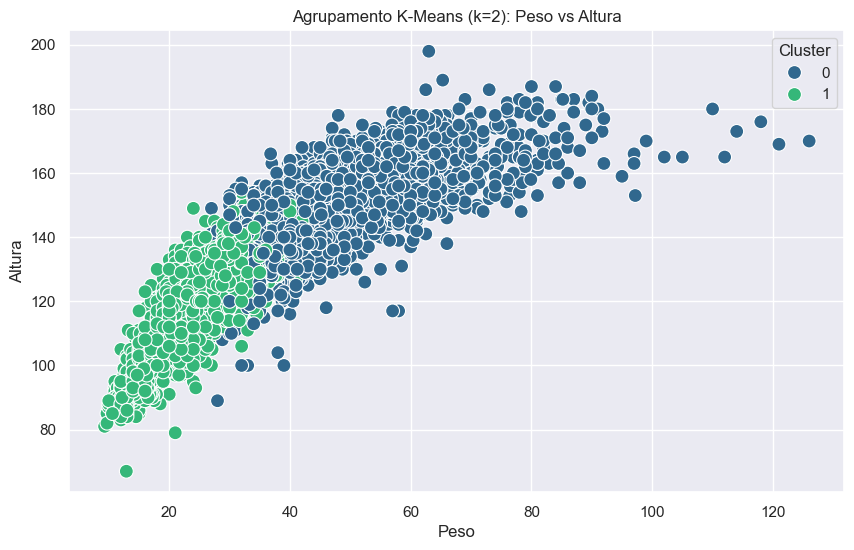

--- Perfil Médio dos Grupos Encontrados ---
              Peso      Altura        IMC      Idade         SBP        DBP  \
Cluster                                                                       
0        47.712586  149.875354  21.089790  11.644678  107.841360  66.820720   
1        22.961224  116.640241  16.658394   5.988226   96.539246  59.081894   

                FC  
Cluster             
0        80.433428  
1        88.744113  


In [392]:
k_escolhido = 2

# 1. Treinar o modelo
kmeans_final = KMeans(n_clusters=k_escolhido, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_cluster)

# 2. Adicionar os clusters ao dataframe original para podermos ler os dados
# Usamos o df_clean para ter os valores reais (não escalados)
df_results = df_clean.copy()
df_results['Cluster'] = clusters

# 3. Visualizar: Scatterplot de Peso vs Altura pintado pelo Cluster
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_results, x='Peso', y='Altura', hue='Cluster', palette='viridis', s=100)
plt.title(f'Agrupamento K-Means (k={k_escolhido}): Peso vs Altura')
plt.show()

# 4. Ver o "Perfil" médio de cada cluster
print("--- Perfil Médio dos Grupos Encontrados ---")
# Agrupamos pelo Cluster e tiramos a média das variáveis numéricas
print(df_results.groupby('Cluster')[numeric_features].mean())


--- Comparação: Os Clusters batem certo com as Doenças? ---
Patologia  Anormal  Normal
Cluster                   
0              670    1801
1             1520    2302


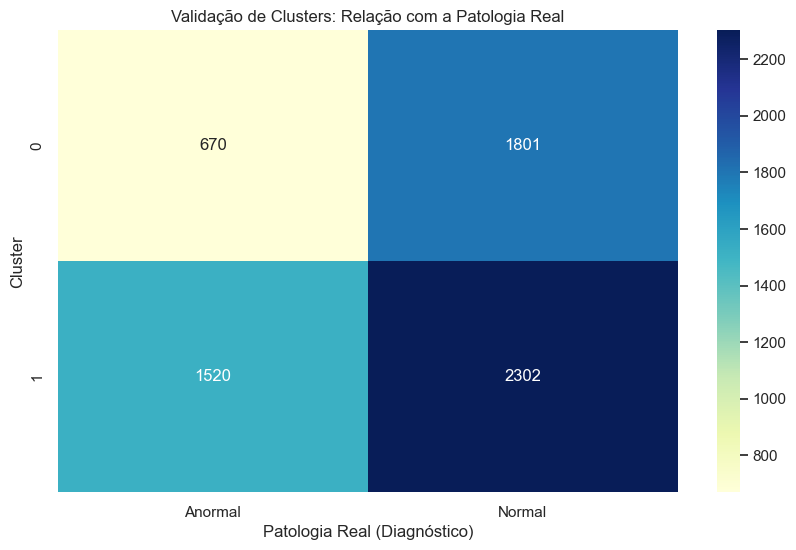

In [393]:
# Tabela de Contingência: Cluster vs Patologia Real
crosstab = pd.crosstab(df_results['Cluster'], df_results['Patologia'])

print("\n--- Comparação: Os Clusters batem certo com as Doenças? ---")
print(crosstab)

# Visualizar com Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Validação de Clusters: Relação com a Patologia Real')
plt.ylabel('Cluster')
plt.xlabel('Patologia Real (Diagnóstico)')
plt.show()

> **Conclusão:** Os clusters formados não correspondem perfeitamente às patologias. Isto indica que a doença não se manifesta exclusivamente através de alterações nas varaivies númericas, sendo necessário utilizar tambénm variáveis categoricas com informação 'clínica' (e.g. Sopro) para a distinção, tal como esta demontrado no ponto  Multiple Linear Regression.

## Predictive models

### Preparation

In [394]:
data = data.rename(columns={
    'Altura':'Altura (cm)',
    'Peso':'Peso (kg)',
    'FC':'FC (bpm)',
    'SBP':'SystolicPressure',
    'DBP' : 'DystolicPressure',
    'B2': 'Second Heart Sound (S2)',
    'HDA1': 'Current Disease History 1 (CDH1)',
    'HDA2': 'Current Disease History 2 (CDH2)',
    'Motivo1': 'Razão Principal',
    'Motivo2': 'Razão Secundária'
    })

1. ```Variáveis que Sofreram Encoding ou Transformação```
Estas são as colunas que vão ser usadas no modelo entrar no modelo:
    * **Scaling (StandardScaler):**
        * Transformar os números para a mesma escala (média 0, desvio 1).
        * Peso (kg)
        * Altura (cm)
        * IMC
        * Idade
        * SystolicPressure (SBP numérica)
        * DystolicPressure (DBP numérica)
        * FC (bpm)
    * **Mapeamento Manual**(.map):
        * Transformar categorias ordinais em números fixos (0, 1, 2).
        * Result SBP-DBP (Transformado usando bp_map)
    * **One-Hot Encoding** (OneHotEncoder):
        * Criar novas colunas binárias para cada categoria.
        * Pulsos
        * Sopro
        * Razão Principal (Corresponde a Motivo1)
        * Current Disease History 1 (CDH1)
        * Second Heart Sound (S2) (Corresponde a B2)
    * **Label Encoding**(LabelEncoder):
        * Transformar em 0 ou 1 numa única coluna.
        * Sexo

2. ```Variáveis que NÃO Sofreram Encoding```
    * Porque tem informação redundante/Informação extra (existe uma váriavel númerica que contém a informação)
        * Systolic Blood Pressure (SBP)
        * Diastolic Blood Pressure (DBP)
        * Percentil IMC
        * Intervalo Idade
        * Razão Secundária (Motivo2)
        * Current Disease History 2 (CDH2)


In [395]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder

# 1. Divisão dos Dados (Essencial para evitar Data Leakage)
# Devemos treinar os transformadores apenas no conjunto de treino
X = data.drop('Patologia', axis=1) # Exemplo: Patologia como target
y = data['Patologia']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Scaling NUMÉRICO ---
# Baseado nas métricas de Peso, Altura, IMC e Pressão 
num_cols = ['Peso (kg)', 'Altura (cm)', 'IMC', 'Idade', 'SystolicPressure', 'DystolicPressure', 'FC (bpm)']
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])
joblib.dump(scaler, 'Assignment/Enconding-map/scaler_final.joblib') # Guardar para novos exemplos 

# --- MAPEAMENTO ESTÁTICO ---
# Seguindo a hierarquia clínica da DGS e tabelas pediátricas 
bp_map = {'Normal': 0, 'Pre-Hipertenso': 1, 'Hipertenso': 2}
#imc_map = {'Baixo EPeso': 0, 'Normal': 1, 'Excesso de Peso': 2, 'Obesidade': 3}

for df in [X_train, X_test]:
    df['Result SBP-DBP'] = df['Result SBP-DBP'].map(bp_map)
    #df['Systolic Blood Pressure (SBP)'] = df['Systolic Blood Pressure (SBP)'].map(bp_map)
    #df['Diastolic Blood Pressure (DBP)'] = df['Diastolic Blood Pressure (DBP)'].map(bp_map)
    #df['Percentil IMC'] = df['Percentil IMC'].map(imc_map)

# --- ENCODING NOMINAL (ONE-HOT) ---
nom_cols = ['Pulsos', 'Sopro', 'Razão Principal', 'Current Disease History 1 (CDH1)' ,'Second Heart Sound (S2)']
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_ohe = ohe.fit_transform(X_train[nom_cols])
X_test_ohe = ohe.transform(X_test[nom_cols])

# Criar DataFrame com as novas colunas e concatenar
ohe_df_train = pd.DataFrame(X_train_ohe, columns=ohe.get_feature_names_out(nom_cols), index=X_train.index)
X_train = pd.concat([X_train.drop(nom_cols, axis=1), ohe_df_train], axis=1)

ohe_df_test = pd.DataFrame(X_test_ohe, columns=ohe.get_feature_names_out(nom_cols), index=X_test.index)
X_test = pd.concat([X_test.drop(nom_cols, axis=1), ohe_df_test], axis=1)

joblib.dump(ohe, 'Assignment/Enconding-map/ohe_final.joblib') # Guardar estado das categorias

# --- LABEL ENCODING (SEXO) ---
le_sexo = LabelEncoder()
X_train['Sexo'] = le_sexo.fit_transform(X_train['Sexo'])
X_test['Sexo'] = le_sexo.transform(X_test['Sexo'])
joblib.dump(le_sexo, 'Assignment/Enconding-map/le_sexo_final.joblib')

['Assignment/Enconding-map/le_sexo_final.joblib']

In [396]:
X_train.T

,4162,5671,505,1894,272,6000,2410,1864,5532,6185,...,5334,466,6265,5734,3092,3772,5191,5226,5390,860
Peso (kg),-1.033927,-1.079477,-1.014405,-1.079477,0.156889,1.132967,0.091817,-0.949333,-0.819189,0.08531,...,-0.49383,0.794593,-0.819189,0.612392,2.174117,1.58847,-1.079477,-0.643495,0.612392,1.198039
Altura (cm),-0.963822,-1.246203,-1.057949,-1.152076,-0.446122,1.342294,0.306895,-0.963822,-0.587313,0.542213,...,0.353958,0.918721,-0.587313,0.730467,1.059912,1.106976,-1.387394,-0.446122,0.589276,1.29523
IMC,-1.126907,-0.861298,-0.92119,-1.009727,1.5422,0.427685,-0.001976,-0.84307,-0.983687,-0.348309,...,-1.319603,0.466745,-0.983687,0.414665,2.651507,1.552616,-0.62173,-0.684226,0.636006,0.59955
Idade,-0.587063,-1.127728,-0.857396,-1.127728,-0.316731,1.305265,0.7646,-0.857396,-0.857396,-0.046398,...,0.494267,1.305265,-0.857396,1.034932,0.7646,1.034932,-1.398061,-0.587063,0.223935,1.034932
SystolicPressure,0.405853,-1.106035,-0.09811,-0.09811,-0.09811,-0.09811,-0.09811,-1.106035,-0.09811,-0.09811,...,0.909816,0.405853,-0.09811,-0.09811,2.925667,-0.09811,-1.106035,-0.09811,-1.106035,0.909816
DystolicPressure,0.356488,-0.261006,-0.261006,-1.495994,-0.261006,-0.261006,0.356488,-0.261006,-0.261006,-0.261006,...,-0.261006,1.591476,0.973982,-0.261006,-0.261006,-0.261006,-1.495994,-0.261006,-1.495994,-0.261006
Result SBP-DBP,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,NaN,0.0,2.0,0.0,0.0,0.0,0.0,0.0
FC (bpm),1.421964,3.382059,0.441917,1.421964,-0.73414,-0.73414,-0.53813,0.441917,1.421964,-0.342121,...,0.245907,0.245907,1.421964,-1.322168,0.245907,-0.73414,1.421964,-0.73414,-1.126159,-2.106206
Current Disease History 2 (CDH2),Assintomático,Assintomático,Assintomático,Palpitacao,Assintomático,Assintomático,Assintomático,Assintomático,Assintomático,Assintomático,...,Assintomático,Assintomático,Assintomático,Assintomático,Assintomático,Assintomático,Assintomático,Assintomático,Assintomático,Assintomático
Sexo,0,0,0,0,0,0,1,1,1,1,...,0,0,0,1,1,1,1,1,1,1



**Cross-validation** is a technique used to check how well a machine learning model performs on unseen data while preventing overfitting. It works by:

* Splitting the dataset into several parts.
* Training the model on some parts and testing it on the remaining part.
* Repeating this resampling process multiple times by choosing different parts of the dataset.
* Averaging the results from each validation step to get the final performance.

### Decision Tree

A decision tree is a type of algorithm used in machine learning for both classification and regression tasks. The algorithm works by recursively splitting the data into smaller subsets based on the values of the input features until a stopping criterion is met. In our case, it's the maximum depth of the tree.

**Parameters:**

* max_depth: This parameter specifies the maximum depth of the tree. A deeper tree can capture more complex interactions in the data but can be computationally expensive. We started with a small depth and later increased it.

In [397]:
# Remover colunas não númericas (todas as colunas que não foram transformadas com label enconding)
non_numeric_cols = X_train.select_dtypes(exclude='number').columns.tolist()
X_train_dt = X_train.drop(non_numeric_cols,axis=1)
X_test_dt = X_test.drop(non_numeric_cols,axis=1)
y_train_dt = y_train
y_test_dt = y_test


In [398]:
from sklearn.model_selection import cross_val_score     
from sklearn.tree import DecisionTreeClassifier

dt1 = DecisionTreeClassifier(max_depth = 3)
dt1.fit(X_train_dt, y_train_dt)
cv_dt1 = cross_val_score(dt1, X_train_dt, y_train_dt, cv = 5)

## Por omissão (default), o cross_val_score utiliza o método .score() do próprio modelo que passamos como argumento.
## Neste caso o Decision tree devolve a accuracy com o método score()
print('Decision Tree Model 1')
print(f'\nCross-validation Accuracy scores:', ', '.join(map(str, cv_dt1)))
print(f'\nMean cross-validation Accuracy score: {cv_dt1.mean():.2f}')

Decision Tree Model 1

Cross-validation Accuracy scores: 0.9185700099304865, 0.9304865938430983, 0.9384309831181727, 0.945382323733863, 0.9214711729622267

Mean cross-validation Accuracy score: 0.93


In [399]:

dt2 = DecisionTreeClassifier(max_depth = 10)
dt2.fit(X_train_dt, y_train_dt)
cv_dt2 = cross_val_score(dt2, X_train_dt, y_train_dt, cv = 5)

## Por omissão (default), o cross_val_score utiliza o método .score() do próprio modelo que passamos como argumento.
## Neste caso o logistic regression devolve a accuracy com o método score()
print('Decision Tree Model 2')
print(f'\nCross-validation Accuracy scores:', ', '.join(map(str, cv_dt2)))
print(f'\nMean cross-validation Accuracy score: {cv_dt2.mean():.2f}')
     

Decision Tree Model 2

Cross-validation Accuracy scores: 0.9066534260178749, 0.9205561072492552, 0.9215491559086395, 0.9205561072492552, 0.9165009940357853

Mean cross-validation Accuracy score: 0.92


### Suport Vector Machines

Support Vector Machine (SVM) is a type of supervised machine learning algorithm used for classification and regression analysis. It works by finding a hyperplane in a high-dimensional space that best separates the data points into different classes.

**Parameters:**

* kernel: The kernel parameter specifies the type of kernel function to use. In this case, we have used rbf and poly kernel.

* C: The C parameter controls the trade-off between maximizing the margin and minimizing the classification error.

* gamma: The gamma parameter is a hyperparameter that determines the influence of a single training example on the decision boundary.

* random_state: This is to ensure that the output is deterministic and can be reproduced.

In [400]:
# Remover colunas não númericas (todas as colunas que não foram transformadas com label enconding)
non_numeric_cols = X_train.select_dtypes(exclude='number').columns.tolist()
X_train_svm = X_train.drop(non_numeric_cols,axis=1).dropna()
X_test_svm = X_test.drop(non_numeric_cols,axis=1).dropna()
y_train_svm = y_train.loc[X_train_svm.index]
y_test_svm = y_test.loc[X_test_svm.index]

In [401]:
from sklearn.svm import SVC

svm1 = SVC(kernel = 'poly', C = 1, random_state = 0, probability = True)
svm1.fit(X_train_svm, y_train_svm)

## Por omissão (default), o cross_val_score utiliza o método .score() do próprio modelo que passamos como argumento.
## Neste caso o logistic regression devolve a accuracy com o método score()
cv_svm1 = cross_val_score(svm1, X_train_svm, y_train_svm, cv = 5)
print('Support Vector Machine Model 1')
print(f'\nCross-validation Accuracy scores:', ', '.join(map(str, cv_svm1)))
print(f'\nMean cross-validation Accuracy score: {cv_svm1.mean():.2f}')

Support Vector Machine Model 1

Cross-validation Accuracy scores: 0.9219251336898395, 0.932620320855615, 0.9400428265524625, 0.9464668094218416, 0.9186295503211992

Mean cross-validation Accuracy score: 0.93


In [402]:
svm2 = SVC(kernel = 'sigmoid', C = 1, gamma = 0.1, random_state = 0, probability = True)
svm2.fit(X_train_svm, y_train_svm)


## Por omissão (default), o cross_val_score utiliza o método .score() do próprio modelo que passamos como argumento.
## Neste caso o logistic regression devolve a accuracy com o método score()
cv_svm2 = cross_val_score(svm2, X_train_svm, y_train_svm, cv = 5)
print('Support Vector Machine Model 2')
print(f'\nCross-validation Accuracy scores:', ', '.join(map(str, cv_svm2)))
print(f'\nMean cross-validation Accuracy score: {cv_svm2.mean():.2f}')

Support Vector Machine Model 2

Cross-validation Accuracy scores: 0.7080213903743315, 0.7272727272727273, 0.7526766595289079, 0.7259100642398287, 0.7259100642398287

Mean cross-validation Accuracy score: 0.73


### Bayesian Networks

The model implemented is a Categorical Naive Bayes (CNB) classifier, a specialized probabilistic algorithm based on Bayes' Theorem. It is designed specifically for datasets where features are categorical (discrete) rather than continuous, making it ideal for clinical variables like "Sopro" (Murmur) or "Motivo" (Reason for Visit).

**Parameters**:

* alpha (Additive / Laplace Smoothing): This parameter controls the smoothing applied to the model. It addresses the "Zero-Frequency Problem," where a categorical feature value appears in the test set but was never seen during training.
* fit_prior (Prior Class Probability):  This parameter determines whether the model should learn the prior probabilities of the classes (e.g., how common "Normal" is vs. "Anormal") from the training data.

In [403]:
data.columns

Index(['Peso (kg)', 'Altura (cm)', 'IMC', 'Idade', 'Pulsos',
       'SystolicPressure', 'DystolicPressure', 'Result SBP-DBP',
       'Second Heart Sound (S2)', 'Sopro', 'FC (bpm)',
       'Current Disease History 1 (CDH1)', 'Current Disease History 2 (CDH2)',
       'Sexo', 'Razão Principal', 'Razão Secundária', 'Intervalo Idade',
       'Percentil IMC', 'Systolic Blood Pressure (SBP)',
       'Diastolic Blood Pressure (DBP)', 'Patologia'],
      dtype='object')

In [404]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# 1. Selecionar o "Dream Team" (Nomes exatos do teu output)
cols_bayes = [
    'Patologia',                        # Alvo
    'Sexo',
    'Intervalo Idade',                  # Em vez de Idade
    'Percentil IMC',                    # Em vez de Peso/Altura
    'Result SBP-DBP',                   # Em vez de SBP/DBP
    'Sopro',
    'Second Heart Sound (S2)',                               
    'Pulsos',
    'Razão Principal',                  # Razão Principal
    'Razão Secundária',                 # Razão Secundária 
    'Current Disease History 1 (CDH1)', # História Doença Atual 1
    'Current Disease History 2 (CDH2)', # História Doença Atual 2
    'FC (bpm)'                          # Frequência Cardíaca (única numérica a tratar)
]

# Criar o DataFrame específico
df_bayes = data[cols_bayes].copy()
df_bayes = df_bayes.dropna()

# 2. DISCRETIZAÇÃO: Transformar a única numérica (FC) em categorias
# Criamos 3 níveis: Baixa, Média, Alta (baseado nos quartis dos dados)
df_bayes['FC_Categ'] = pd.qcut(df_bayes['FC (bpm)'], q=3, labels=['Baixa', 'Media', 'Alta'])

# Remover a coluna numérica original
df_bayes = df_bayes.drop('FC (bpm)', axis=1)

# 3. LABEL ENCODING (Transformar Texto em Números 0, 1, 2...)
# Redes Bayesianas preferem números inteiros a representar categorias

le_dict = {} # Guardar os "dicionários" para saberes o que significa 0, 1, 2 depois

print("--- Mapeamento das Variáveis ---")
for col in df_bayes.columns:
    # Preencher vazios com 'Desconhecido' e garantir que é texto
    
    # Criar Encoder
    le = LabelEncoder()
    df_bayes[col] = le.fit_transform(df_bayes[col])
    
    # Guardar no dicionário
    le_dict[col] = le
    
    # Mostrar quantos estados tem cada nó (importante para a complexidade da rede)
    print(f"> {col}: {len(le.classes_)} estados {le.classes_}")


# Exemplo: Verificar quem é quem na Patologia
print("\nLegenda Patologia:", dict(zip(le_dict['Patologia'].classes_, le_dict['Patologia'].transform(le_dict['Patologia'].classes_))))

--- Mapeamento das Variáveis ---
> Patologia: 2 estados ['Anormal' 'Normal']
> Sexo: 2 estados ['Feminino' 'Masculino']
> Intervalo Idade: 4 estados ['Pre-School [2,6[' 'Pre-Teen [10,14[' 'School [6-10[' 'Teenager [14,19[']
> Percentil IMC: 4 estados ['Low Weigth' 'Normal' 'Obese' 'Overweigth']
> Result SBP-DBP: 3 estados ['Hipertenso' 'Normal' 'Pre-hipertenso']
> Sopro: 4 estados ['Ausente' 'Contínuo' 'Diastólico' 'Sistólico']
> Second Heart Sound (S2): 4 estados ['Fixed Split' 'Hyperphonetic' 'Normal' 'Unique']
> Pulsos: 3 estados ['Ample' 'Diminished Femoral' 'Normal']
> Razão Principal: 5 estados ['Cardiopatia' 'Checkup de rotina' 'Outros' 'Possivel cardiopatia'
 'Triagem Cardiológica']
> Razão Secundária: 6 estados ['Atividade física' 'Cardiopatia congenica' 'Cirurgia' 'Fatores de risco'
 'Outros' 'Presença de Sopro']
> Current Disease History 1 (CDH1): 7 estados ['Assintomático' 'Cianose' 'Desmaio/tontura' 'Dispneia' 'Dor precordial'
 'Ganho de peso' 'Palpitacao']
> Current Disea

In [405]:
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.naive_bayes import CategoricalNB, MultinomialNB

# 1. Separar Features e Target do dataset de Bayes
X_b = df_bayes.drop('Patologia', axis=1)
y_b = df_bayes['Patologia']

X_train_bn, X_test_bn, y_train_bn, y_test_bn = train_test_split(X_b, y_b, test_size=0.3, random_state=42)

print(f"Dados prontos para Bayes. Treino shape: {X_train_bn.shape}")

Dados prontos para Bayes. Treino shape: (4405, 12)


In [406]:
# --- MODELO 1: Categorical Naive Bayes (Padrão) ---
# alpha=1.0 aplica "Laplace Smoothing" (evita probabilidades de 0% se uma categoria nunca tiver sido vista)
baen1 = CategoricalNB(alpha=1.0) 
baen1.fit(X_train_bn, y_train_bn)

cv_baen1 = cross_val_score(baen1, X_train_bn, y_train_bn, cv=5)

print('Bayesian Network Model 1 (CategoricalNB - Standard)')
print(f'Cross-validation Accuracy scores: {", ".join(map(str, np.round(cv_baen1, 4)))}')
print(f'Mean cross-validation Accuracy score: {cv_baen1.mean():.2f}')



Bayesian Network Model 1 (CategoricalNB - Standard)
Cross-validation Accuracy scores: 0.916, 0.9103, 0.9319, 0.9217, 0.9137
Mean cross-validation Accuracy score: 0.92


In [407]:
# --- MODELO 2: Categorical Naive Bayes (Ajustado) ---
# alpha=0.01: Menos suavização (confia mais nos dados puros, arriscado se houver poucos dados)
# fit_prior=False: Assume uma distribuição uniforme das classes à partida, em vez de aprender a frequência das classes no treino
baen2 = CategoricalNB(alpha=0.01, fit_prior=False)
baen2.fit(X_train_bn, y_train_bn)

cv_baen2 = cross_val_score(baen2, X_train_bn, y_train_bn, cv=5)

print('Bayesian Network Model 2 (CategoricalNB - Tuned)')
print(f'Cross-validation Accuracy scores: {", ".join(map(str, np.round(cv_baen2, 4)))}')
print(f'Mean cross-validation Accuracy score: {cv_baen2.mean():.2f}')

Bayesian Network Model 2 (CategoricalNB - Tuned)
Cross-validation Accuracy scores: 0.9035, 0.9024, 0.924, 0.9058, 0.9035
Mean cross-validation Accuracy score: 0.91


## Comparison

In [408]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report, \
 roc_auc_score, roc_curve, auc, precision_recall_curve
     

### Decision tree Models comparison

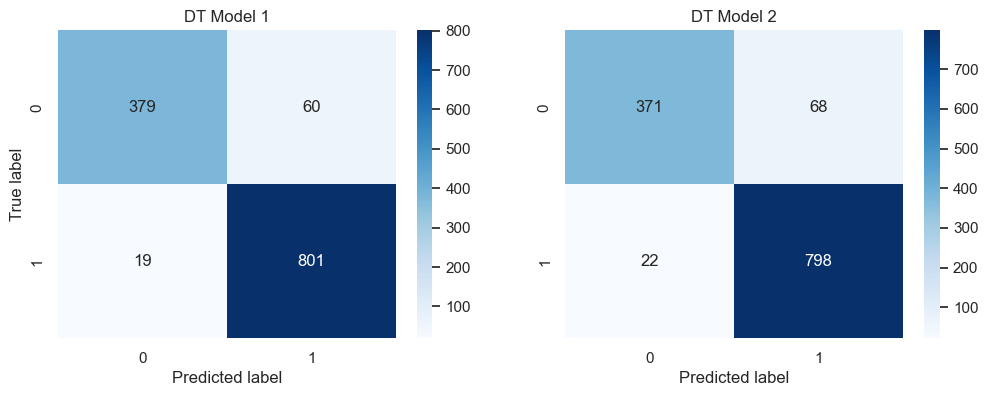

In [409]:
y_pred_dt1 = dt1.predict(X_test_dt)
y_pred_dt2 = dt2.predict(X_test_dt)

conf_matrix_model1 = confusion_matrix(y_test_dt, y_pred_dt1)
conf_matrix_model2 = confusion_matrix(y_test_dt, y_pred_dt2)

fig, axs = plt.subplots(1, 2, figsize = (12, 4))

sns.heatmap(conf_matrix_model1, annot = True, fmt='d', cmap = 'Blues', ax = axs[0])
axs[0].set_title('DT Model 1')

sns.heatmap(conf_matrix_model2, annot = True,fmt='d', cmap = 'Blues', ax = axs[1])
axs[1].set_title('DT Model 2')

axs[0].set_xlabel('Predicted label')
axs[0].set_ylabel('True label')
axs[1].set_xlabel('Predicted label')
plt.show()

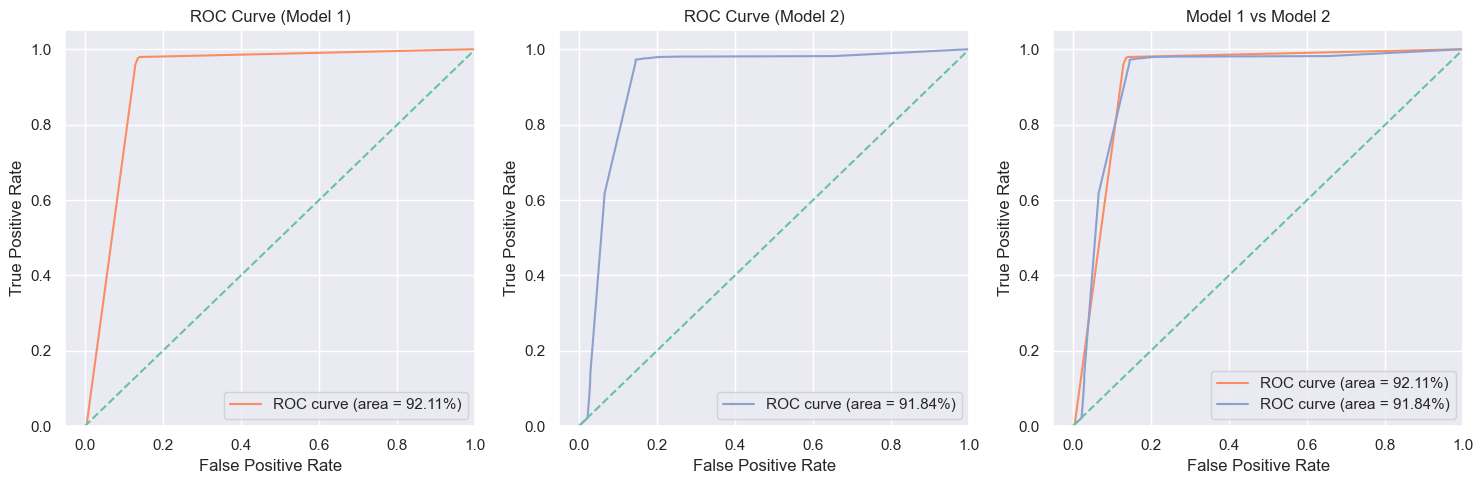

In [410]:
colors = sns.color_palette('Set2', n_colors = 3)

y_prob_dt1 = dt1.predict_proba(X_test_dt)[:,1]
y_prob_dt2 = dt2.predict_proba(X_test_dt)[:,1]

mapa_patologia = {'Anormal': 0, 'Normal': 1}
y_test_dt = y_test_dt.map(mapa_patologia)

fpr1, tpr1, _ = roc_curve(y_test_dt, y_prob_dt1)
roc_auc1 = auc(fpr1, tpr1)

fpr2, tpr2, _ = roc_curve(y_test_dt, y_prob_dt2)
roc_auc2 = auc(fpr2, tpr2)

fig, axes = plt.subplots(1, 3, figsize = (15, 5))

axes[0].plot(fpr1, tpr1, label = f'ROC curve (area = {roc_auc1:.2%})', color = colors[1])
axes[0].plot([0, 1], [0, 1], color = colors[0], linestyle = '--')
axes[0].set_xlim([-0.05, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve (Model 1)')
axes[0].legend(loc = 'lower right')

axes[1].plot(fpr2, tpr2, label = f'ROC curve (area = {roc_auc2:.2%})', color = colors[2])
axes[1].plot([0, 1], [0, 1], color = colors[0], linestyle = '--')
axes[1].set_xlim([-0.05, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve (Model 2)')
axes[1].legend(loc = 'lower right')

axes[2].plot(fpr1, tpr1, label = f'ROC curve (area = {roc_auc1:.2%})', color = colors[1])
axes[2].plot(fpr2, tpr2, label = f'ROC curve (area = {roc_auc2:.2%})', color = colors[2])
axes[2].plot([0, 1], [0, 1], color = colors[0], linestyle = '--')
axes[2].set_xlim([-0.05, 1.0])
axes[2].set_ylim([0.0, 1.05])
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('Model 1 vs Model 2')
axes[2].legend(loc = 'lower right')

plt.tight_layout()
plt.show()

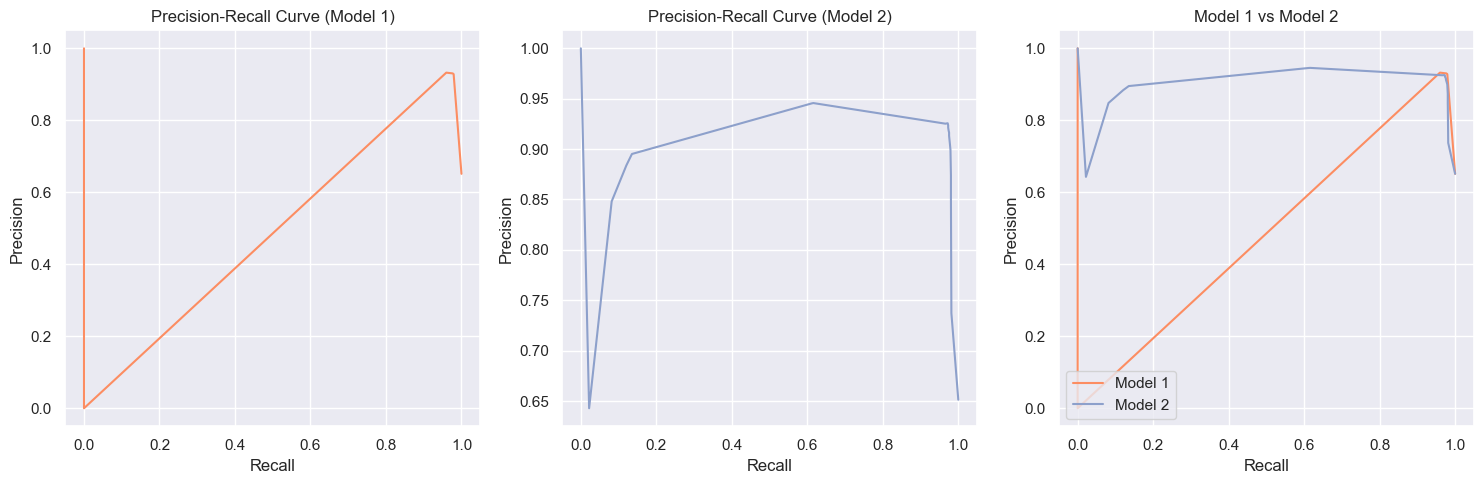

In [411]:
precision1, recall1, threshold1 = precision_recall_curve(y_test_dt, y_prob_dt1)
precision2, recall2, threshold2 = precision_recall_curve(y_test_dt, y_prob_dt2)

fig, axs = plt.subplots(1, 3, figsize = (15, 5))

axs[0].plot(recall1, precision1, color = colors[1], label = 'Model 1')
axs[0].set_xlabel('Recall')
axs[0].set_ylabel('Precision')
axs[0].set_title('Precision-Recall Curve (Model 1)')

axs[1].plot(recall2, precision2, color = colors[2], label = 'Model 2')
axs[1].set_xlabel('Recall')
axs[1].set_ylabel('Precision')
axs[1].set_title('Precision-Recall Curve (Model 2)')

axs[2].plot(recall1, precision1, color = colors[1], label = 'Model 1')
axs[2].plot(recall2, precision2, color = colors[2], label = 'Model 2')
axs[2].set_xlabel('Recall')
axs[2].set_ylabel('Precision')
axs[2].set_title('Model 1 vs Model 2')
axs[2].legend(loc = 'lower left')

plt.tight_layout()
plt.show()

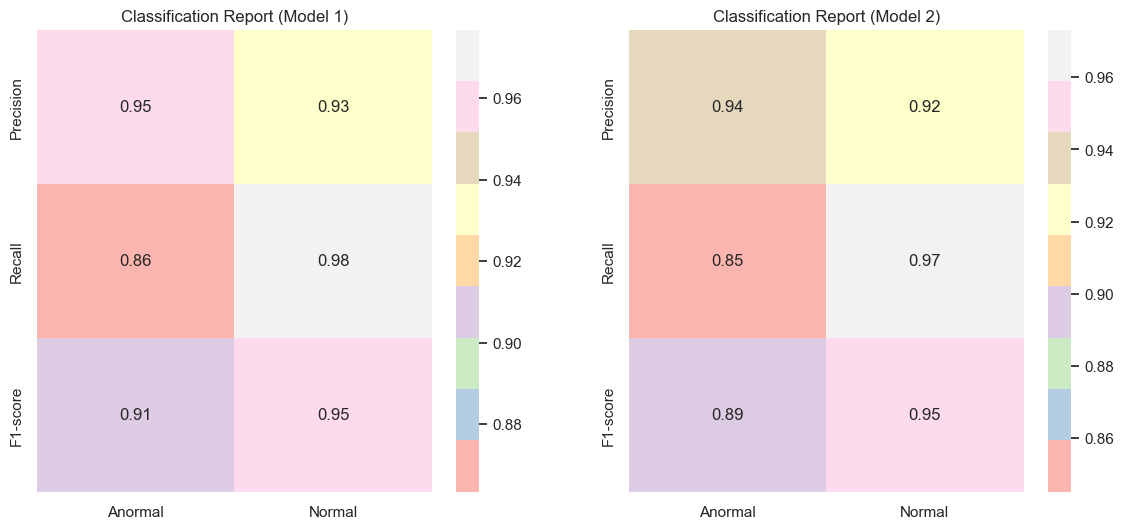

In [412]:
#  'Anormal' -> 0  'Normal' -> 1
y_pred_dt1 = [1 if x == 'Normal' else 0 for x in y_pred_dt1]
y_pred_dt2 = [1 if x == 'Normal' else 0 for x in y_pred_dt2]

target_names = dt1.classes_
metrics1 = classification_report(y_true = y_test_dt, y_pred = y_pred_dt1, target_names = target_names, output_dict = True)
precision1 = [metrics1[target_name]['precision'] for target_name in target_names]
recall1 = [metrics1[target_name]['recall'] for target_name in target_names]
f1_score1 = [metrics1[target_name]['f1-score'] for target_name in target_names]

metrics2 = classification_report(y_true = y_test_dt, y_pred = y_pred_dt2, target_names = target_names, output_dict = True)
precision2 = [metrics2[target_name]['precision'] for target_name in target_names]
recall2 = [metrics2[target_name]['recall'] for target_name in target_names]
f1_score2 = [metrics2[target_name]['f1-score'] for target_name in target_names]

data1 = np.array([precision1, recall1, f1_score1])
data2 = np.array([precision2, recall2, f1_score2])
rows = ['Precision', 'Recall', 'F1-score']

fig, axs = plt.subplots(1, 2, figsize = (14, 6))
sns.heatmap(data1, cmap='Pastel1', annot = True, fmt='.2f', xticklabels = target_names, yticklabels = rows, ax = axs[0])
sns.heatmap(data2, cmap = 'Pastel1', annot = True, fmt = '.2f', xticklabels = target_names, yticklabels = rows, ax = axs[1])
axs[0].set_title('Classification Report (Model 1)')
axs[1].set_title('Classification Report (Model 2)')
plt.show()

### Suport Vector Machine Models comparison

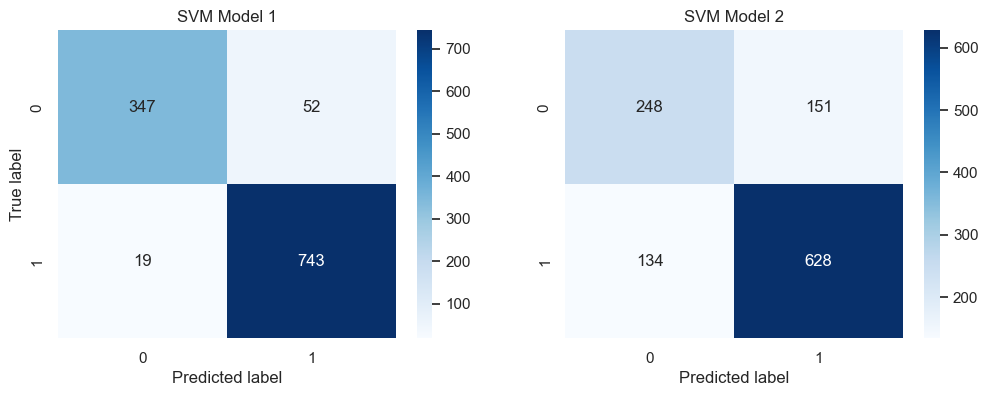

In [413]:
y_pred_svm1 = svm1.predict(X_test_svm)
y_pred_svm2 = svm2.predict(X_test_svm)

conf_matrix_model1 = confusion_matrix(y_test_svm, y_pred_svm1)
conf_matrix_model2 = confusion_matrix(y_test_svm, y_pred_svm2)

fig, axs = plt.subplots(1, 2, figsize = (12, 4))

sns.heatmap(conf_matrix_model1, annot = True, fmt='d', cmap = 'Blues', ax = axs[0])
axs[0].set_title('SVM Model 1')

sns.heatmap(conf_matrix_model2, annot = True,fmt='d', cmap = 'Blues', ax = axs[1])
axs[1].set_title('SVM Model 2')

axs[0].set_xlabel('Predicted label')
axs[0].set_ylabel('True label')
axs[1].set_xlabel('Predicted label')
plt.show()

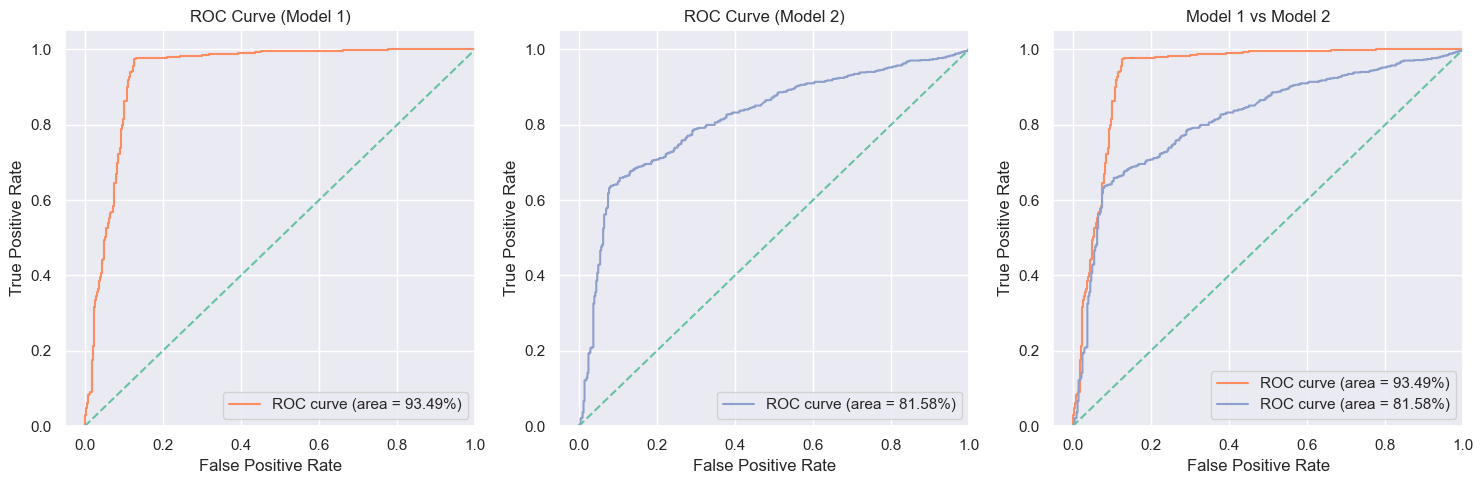

In [414]:
colors = sns.color_palette('Set2', n_colors = 3)

y_prob_svm1 = svm1.predict_proba(X_test_svm)[:,1]
y_prob_svm2 = svm2.predict_proba(X_test_svm)[:,1]

mapa_patologia = {'Anormal': 0, 'Normal': 1}
y_test_svm = y_test_svm.map(mapa_patologia)

fpr1, tpr1, _ = roc_curve(y_test_svm, y_prob_svm1)
roc_auc1 = auc(fpr1, tpr1)

fpr2, tpr2, _ = roc_curve(y_test_svm, y_prob_svm2)
roc_auc2 = auc(fpr2, tpr2)

fig, axes = plt.subplots(1, 3, figsize = (15, 5))

axes[0].plot(fpr1, tpr1, label = f'ROC curve (area = {roc_auc1:.2%})', color = colors[1])
axes[0].plot([0, 1], [0, 1], color = colors[0], linestyle = '--')
axes[0].set_xlim([-0.05, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve (Model 1)')
axes[0].legend(loc = 'lower right')

axes[1].plot(fpr2, tpr2, label = f'ROC curve (area = {roc_auc2:.2%})', color = colors[2])
axes[1].plot([0, 1], [0, 1], color = colors[0], linestyle = '--')
axes[1].set_xlim([-0.05, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve (Model 2)')
axes[1].legend(loc = 'lower right')

axes[2].plot(fpr1, tpr1, label = f'ROC curve (area = {roc_auc1:.2%})', color = colors[1])
axes[2].plot(fpr2, tpr2, label = f'ROC curve (area = {roc_auc2:.2%})', color = colors[2])
axes[2].plot([0, 1], [0, 1], color = colors[0], linestyle = '--')
axes[2].set_xlim([-0.05, 1.0])
axes[2].set_ylim([0.0, 1.05])
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('Model 1 vs Model 2')
axes[2].legend(loc = 'lower right')

plt.tight_layout()
plt.show()

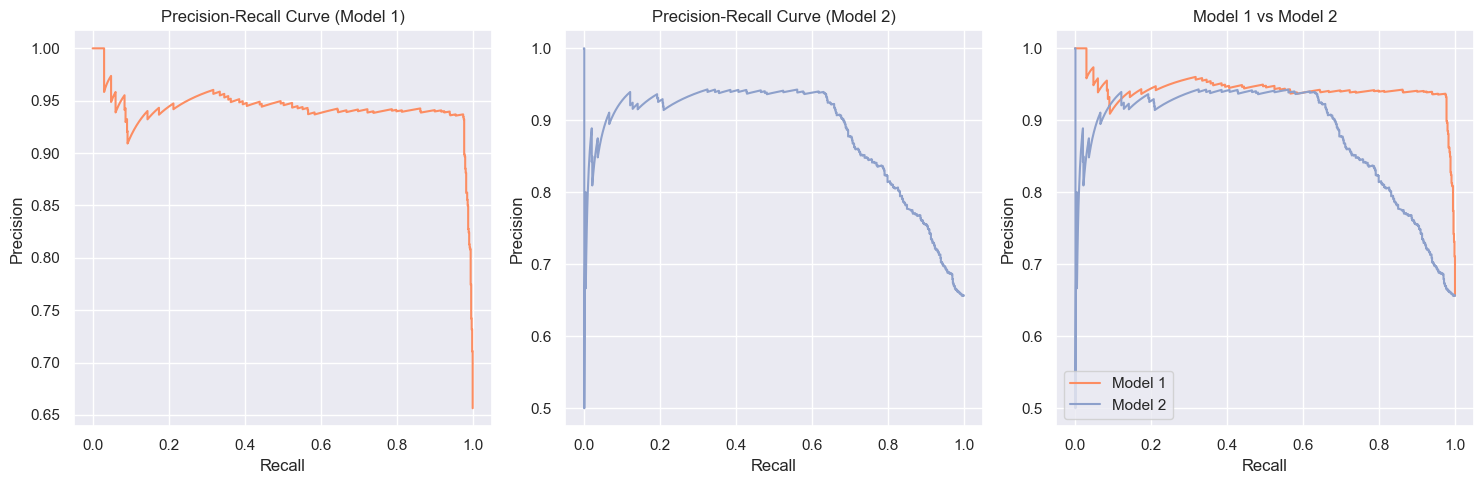

In [415]:
precision1, recall1, threshold1 = precision_recall_curve(y_test_svm, y_prob_svm1)
precision2, recall2, threshold2 = precision_recall_curve(y_test_svm, y_prob_svm2)

fig, axs = plt.subplots(1, 3, figsize = (15, 5))

axs[0].plot(recall1, precision1, color = colors[1], label = 'Model 1')
axs[0].set_xlabel('Recall')
axs[0].set_ylabel('Precision')
axs[0].set_title('Precision-Recall Curve (Model 1)')

axs[1].plot(recall2, precision2, color = colors[2], label = 'Model 2')
axs[1].set_xlabel('Recall')
axs[1].set_ylabel('Precision')
axs[1].set_title('Precision-Recall Curve (Model 2)')

axs[2].plot(recall1, precision1, color = colors[1], label = 'Model 1')
axs[2].plot(recall2, precision2, color = colors[2], label = 'Model 2')
axs[2].set_xlabel('Recall')
axs[2].set_ylabel('Precision')
axs[2].set_title('Model 1 vs Model 2')
axs[2].legend(loc = 'lower left')

plt.tight_layout()
plt.show()

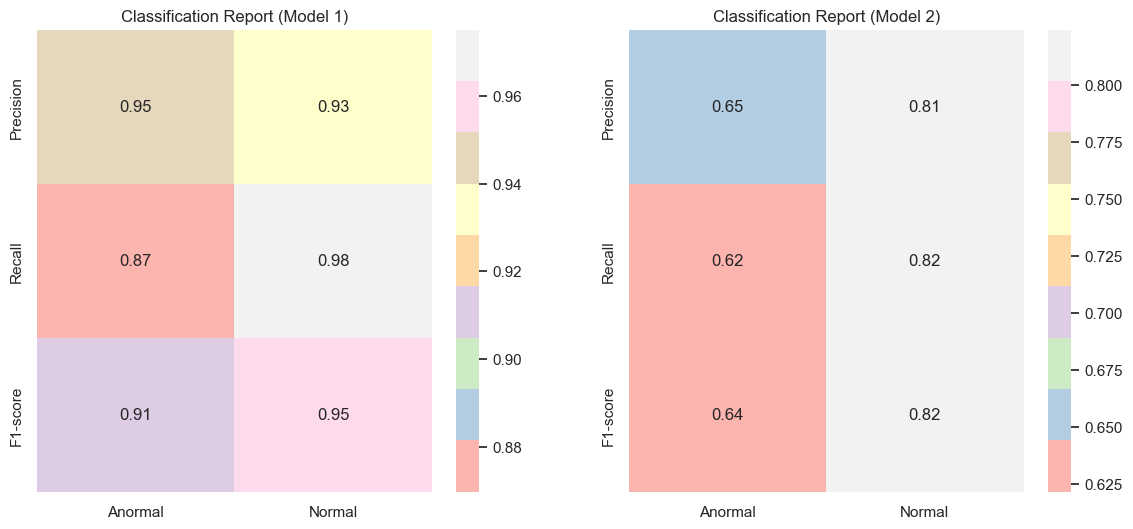

In [416]:
#  'Anormal' -> 0  'Normal' -> 1
y_pred_svm1 = [1 if x == 'Normal' else 0 for x in y_pred_svm1]
y_pred_svm2 = [1 if x == 'Normal' else 0 for x in y_pred_svm2]

target_names = svm1.classes_
metrics1 = classification_report(y_true = y_test_svm, y_pred = y_pred_svm1, target_names = target_names, output_dict = True)
precision1 = [metrics1[target_name]['precision'] for target_name in target_names]
recall1 = [metrics1[target_name]['recall'] for target_name in target_names]
f1_score1 = [metrics1[target_name]['f1-score'] for target_name in target_names]

metrics2 = classification_report(y_true = y_test_svm, y_pred = y_pred_svm2, target_names = target_names, output_dict = True)
precision2 = [metrics2[target_name]['precision'] for target_name in target_names]
recall2 = [metrics2[target_name]['recall'] for target_name in target_names]
f1_score2 = [metrics2[target_name]['f1-score'] for target_name in target_names]

data1 = np.array([precision1, recall1, f1_score1])
data2 = np.array([precision2, recall2, f1_score2])
rows = ['Precision', 'Recall', 'F1-score']

fig, axs = plt.subplots(1, 2, figsize = (14, 6))
sns.heatmap(data1, cmap='Pastel1', annot = True, fmt='.2f', xticklabels = target_names, yticklabels = rows, ax = axs[0])
sns.heatmap(data2, cmap = 'Pastel1', annot = True, fmt = '.2f', xticklabels = target_names, yticklabels = rows, ax = axs[1])
axs[0].set_title('Classification Report (Model 1)')
axs[1].set_title('Classification Report (Model 2)')
plt.show()

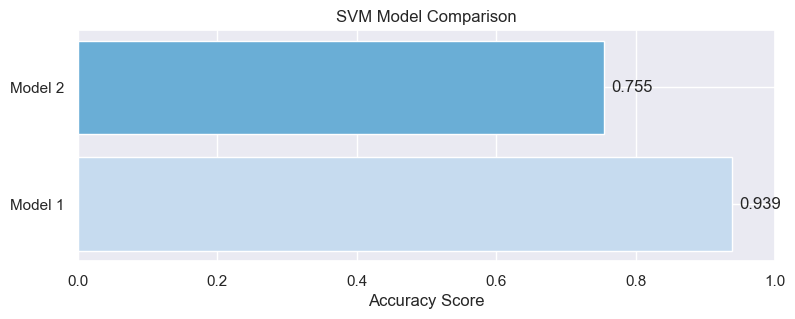

In [417]:
palette = sns.color_palette('Blues', n_colors = 3)

acc1 = accuracy_score(y_pred_svm1, y_test_svm)
acc2 = accuracy_score(y_pred_svm2, y_test_svm)

labels = ['Model 1', 'Model 2']
scores = [acc1, acc2]

fig, ax = plt.subplots(figsize = (9, 3))
ax.barh(labels, scores, color = palette)
ax.set_xlim([0, 1])
ax.set_xlabel('Accuracy Score')
ax.set_title('SVM Model Comparison')

for i, v in enumerate(scores):
    ax.text(v + 0.01, i, str(round(v, 3)), ha = 'left', va = 'center')

plt.show()

### Bayesean network Models comparison

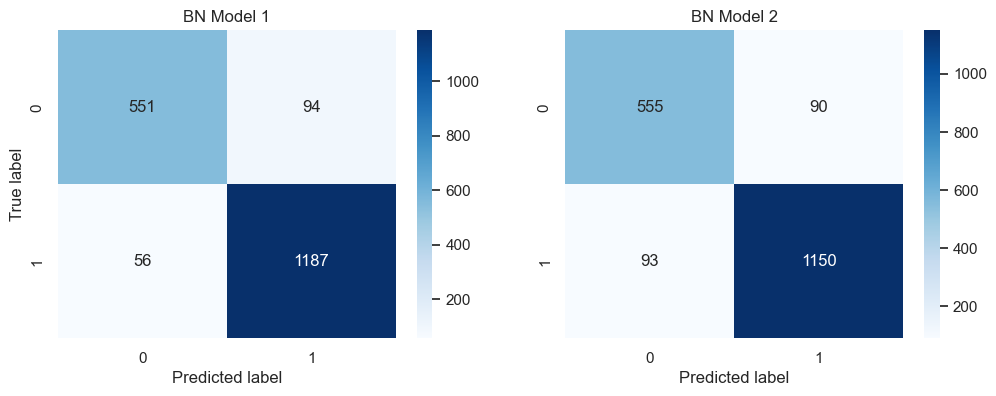

In [418]:
y_pred_baen1 = baen1.predict(X_test_bn)
y_pred_baen2 = baen2.predict(X_test_bn)

conf_matrix_model1 = confusion_matrix(y_test_bn, y_pred_baen1 )
conf_matrix_model2 = confusion_matrix(y_test_bn, y_pred_baen2)

fig, axs = plt.subplots(1, 2, figsize = (12, 4))

sns.heatmap(conf_matrix_model1, annot = True, fmt='d', cmap = 'Blues', ax = axs[0])
axs[0].set_title('BN Model 1')

sns.heatmap(conf_matrix_model2, annot = True,fmt='d', cmap = 'Blues', ax = axs[1])
axs[1].set_title('BN Model 2')

axs[0].set_xlabel('Predicted label')
axs[0].set_ylabel('True label')
axs[1].set_xlabel('Predicted label')
plt.show()

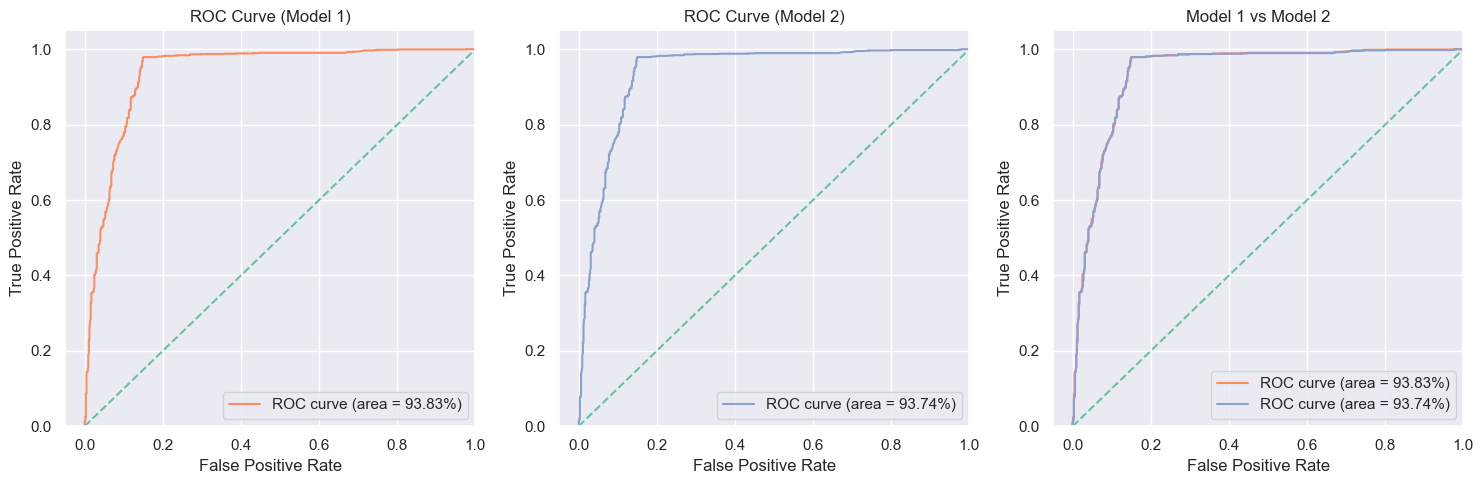

In [ ]:
colors = sns.color_palette('Set2', n_colors = 3)

y_prob_baen1 = baen1.predict_proba(X_test_bn)[:,1]
y_prob_baen2 = baen2.predict_proba(X_test_bn)[:,1]

# y_test_bn não precisa de mapear para 0 e 1 porque já esta mapeado
fpr1, tpr1, _ = roc_curve(y_test_bn, y_prob_baen1)
roc_auc1 = auc(fpr1, tpr1)

fpr2, tpr2, _ = roc_curve(y_test_bn, y_prob_baen2)
roc_auc2 = auc(fpr2, tpr2)

fig, axes = plt.subplots(1, 3, figsize = (15, 5))

axes[0].plot(fpr1, tpr1, label = f'ROC curve (area = {roc_auc1:.2%})', color = colors[1])
axes[0].plot([0, 1], [0, 1], color = colors[0], linestyle = '--')
axes[0].set_xlim([-0.05, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve (Model 1)')
axes[0].legend(loc = 'lower right')

axes[1].plot(fpr2, tpr2, label = f'ROC curve (area = {roc_auc2:.2%})', color = colors[2])
axes[1].plot([0, 1], [0, 1], color = colors[0], linestyle = '--')
axes[1].set_xlim([-0.05, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve (Model 2)')
axes[1].legend(loc = 'lower right')

axes[2].plot(fpr1, tpr1, label = f'ROC curve (area = {roc_auc1:.2%})', color = colors[1])
axes[2].plot(fpr2, tpr2, label = f'ROC curve (area = {roc_auc2:.2%})', color = colors[2])
axes[2].plot([0, 1], [0, 1], color = colors[0], linestyle = '--')
axes[2].set_xlim([-0.05, 1.0])
axes[2].set_ylim([0.0, 1.05])
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('Model 1 vs Model 2')
axes[2].legend(loc = 'lower right')

plt.tight_layout()
plt.show()

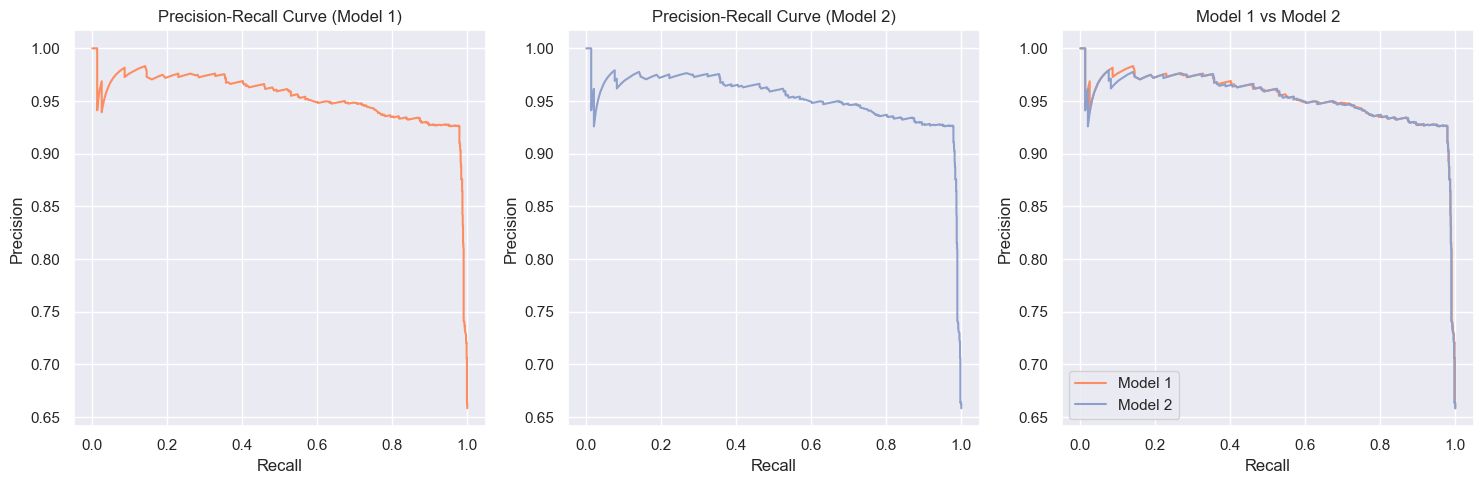

In [421]:
precision1, recall1, threshold1 = precision_recall_curve(y_test_bn, y_prob_baen1)
precision2, recall2, threshold2 = precision_recall_curve(y_test_bn, y_prob_baen2)

fig, axs = plt.subplots(1, 3, figsize = (15, 5))

axs[0].plot(recall1, precision1, color = colors[1], label = 'Model 1')
axs[0].set_xlabel('Recall')
axs[0].set_ylabel('Precision')
axs[0].set_title('Precision-Recall Curve (Model 1)')

axs[1].plot(recall2, precision2, color = colors[2], label = 'Model 2')
axs[1].set_xlabel('Recall')
axs[1].set_ylabel('Precision')
axs[1].set_title('Precision-Recall Curve (Model 2)')

axs[2].plot(recall1, precision1, color = colors[1], label = 'Model 1')
axs[2].plot(recall2, precision2, color = colors[2], label = 'Model 2')
axs[2].set_xlabel('Recall')
axs[2].set_ylabel('Precision')
axs[2].set_title('Model 1 vs Model 2')
axs[2].legend(loc = 'lower left')

plt.tight_layout()
plt.show()

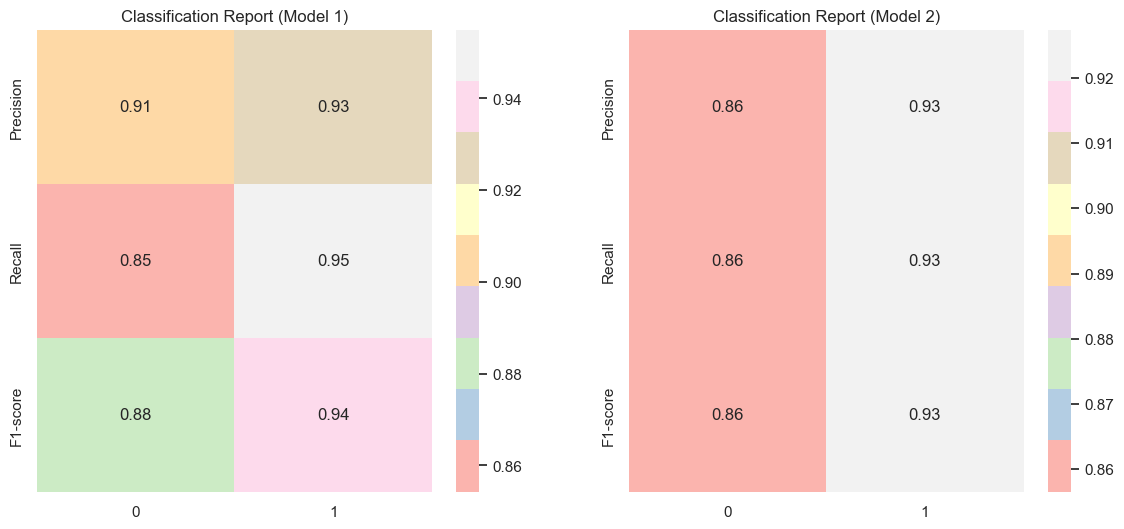

In [423]:
target_names = baen1.classes_
metrics1 = classification_report(y_true = y_test_bn, y_pred = y_pred_baen1, target_names = target_names, output_dict = True)
precision1 = [metrics1[target_name]['precision'] for target_name in target_names]
recall1 = [metrics1[target_name]['recall'] for target_name in target_names]
f1_score1 = [metrics1[target_name]['f1-score'] for target_name in target_names]

metrics2 = classification_report(y_true = y_test_bn, y_pred = y_pred_baen2, target_names = target_names, output_dict = True)
precision2 = [metrics2[target_name]['precision'] for target_name in target_names]
recall2 = [metrics2[target_name]['recall'] for target_name in target_names]
f1_score2 = [metrics2[target_name]['f1-score'] for target_name in target_names]

data1 = np.array([precision1, recall1, f1_score1])
data2 = np.array([precision2, recall2, f1_score2])
rows = ['Precision', 'Recall', 'F1-score']

fig, axs = plt.subplots(1, 2, figsize = (14, 6))
sns.heatmap(data1, cmap='Pastel1', annot = True, fmt='.2f', xticklabels = target_names, yticklabels = rows, ax = axs[0])
sns.heatmap(data2, cmap = 'Pastel1', annot = True, fmt = '.2f', xticklabels = target_names, yticklabels = rows, ax = axs[1])
axs[0].set_title('Classification Report (Model 1)')
axs[1].set_title('Classification Report (Model 2)')
plt.show()

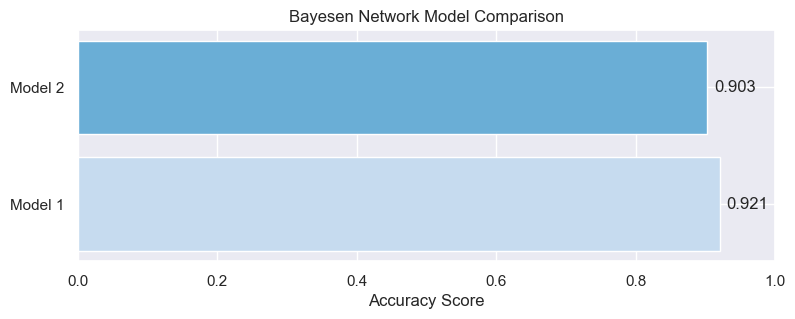

In [424]:
palette = sns.color_palette('Blues', n_colors = 3)

acc1 = accuracy_score(y_pred_baen1, y_test_bn)
acc2 = accuracy_score(y_pred_baen2, y_test_bn)

labels = ['Model 1', 'Model 2']
scores = [acc1, acc2]

fig, ax = plt.subplots(figsize = (9, 3))
ax.barh(labels, scores, color = palette)
ax.set_xlim([0, 1])
ax.set_xlabel('Accuracy Score')
ax.set_title('Bayesen Network Model Comparison')

for i, v in enumerate(scores):
    ax.text(v + 0.01, i, str(round(v, 3)), ha = 'left', va = 'center')

plt.show()